# AI-Driven Multi-Omics Disease Subtyping Using a Variational Autoencoder

**Workshop Notebook 1 — ~2 hours**

**Biological question:** *Can a neural network learn a compact representation of breast cancer patients from multiple molecular layers and reveal biologically meaningful patient subgroups?*

---

**Dataset:** TCGA-BRCA (The Cancer Genome Atlas — Breast Invasive Carcinoma)  
**Omics layers:** RNA-seq gene expression · DNA methylation (CpG) · miRNA expression  
**Reference labels (post-hoc only):** PAM50 molecular subtypes  
**Model:** Variational Autoencoder (VAE, PyTorch)  
**Hardware requirement:** Standard CPU — no GPU needed

---
## Section 1 — Introduction

### What is disease subtyping?

**Disease subtyping** is the task of partitioning patients with the same clinical diagnosis into molecularly distinct groups. Different subtypes may have different prognoses, respond differently to therapies, and arise from different biological mechanisms.

### Why does breast cancer have molecularly distinct subgroups?

Breast cancer is a heterogeneous disease. Even though all tumours are diagnosed as "breast cancer," they differ fundamentally at the molecular level. The **PAM50** gene expression signature defines five established subtypes:

| Subtype | Key biology |
|---|---|
| Luminal A | ER+, low proliferation, best prognosis |
| Luminal B | ER+, higher proliferation |
| HER2-enriched | ERBB2 amplification |
| Basal-like | Triple-negative, aggressive |
| Normal-like | Resembles normal breast tissue |

These subtypes differ in gene expression, methylation, miRNA regulation, and clinical outcome — making them ideal for multi-omics integration.

### Why integrate multiple omics layers?

Each molecular layer captures a **different aspect of tumour biology**:
- **RNA-seq** measures transcriptional activity — which genes are being expressed
- **DNA methylation** captures epigenetic regulation — which regions are silenced
- **miRNA** captures post-transcriptional regulation — small RNAs that suppress gene expression

No single layer tells the full story. Integration can reveal patterns invisible in any one modality alone.

### What is representation learning?

Instead of manually engineering features, we let a neural network **learn a compact, informative representation** of patients. The goal is a low-dimensional "patient embedding" that captures the important variation across all three molecular layers.

### Why a Variational Autoencoder?

A VAE learns a **probabilistic latent space** that:
1. Compresses thousands of molecular measurements into a small number of learned variables
2. Can capture **nonlinear** relationships that linear methods (like PCA) miss
3. Forces the latent space to be smooth and continuous, making it suitable for downstream clustering and visualization
4. Is fully interpretable in terms of reconstruction and regularisation objectives

> ⚠️ **Key concept:** The VAE is trained **without** any subtype labels. The discovery of patient structure is entirely unsupervised. PAM50 labels are only used *after* training to assess biological relevance.

---
## Section 2 — Dataset: TCGA-BRCA

The **Cancer Genome Atlas Breast Invasive Carcinoma (TCGA-BRCA)** project profiled ~1,000 primary breast tumours with matched multi-omics measurements.

### Molecular data layers we will use

| Layer | Measurement | Typical raw format | Size |
|---|---|---|---|
| **RNA-seq** | mRNA gene expression | Raw counts or FPKM/TPM | ~60,000 genes |
| **DNA methylation** | CpG beta values (0–1) | Illumina 450K or EPIC array | ~450,000–850,000 sites |
| **miRNA** | small RNA expression | Read counts | ~2,500 mature miRNAs |

### PAM50 molecular subtypes

PAM50 is a **50-gene classifier** that assigns each tumour to one of five molecular subtypes. In this notebook, PAM50 serves two roles:

| Role | When | Purpose |
|---|---|---|
| ❌ **NOT** a training input | During VAE training | We do **not** use it |
| ✅ **Post-hoc interpretation** | After unsupervised clustering | Evaluate biological relevance |

This distinction is critical: if we used PAM50 labels during training, we would be doing supervised classification, not unsupervised representation learning.

### Expected data files

The notebook expects the following preprocessed matrix files in a `data/` subdirectory:

```
data/
  tcga_brca_rnaseq.csv          # rows = patients (TCGA barcodes), cols = genes
  tcga_brca_methylation.csv     # rows = patients, cols = CpG probes
  tcga_brca_mirna.csv           # rows = patients, cols = miRNA IDs
  tcga_brca_pam50.csv           # rows = patients, col = PAM50 subtype label
```

If these files are not present, the notebook will print instructions for obtaining them from the GDC data portal.

---
## Section 1 (Code) — Import Libraries & Set Global Random Seeds

We import all required libraries upfront and set random seeds everywhere to ensure **full reproducibility**.  
Note: Results may still vary slightly across different hardware/OS combinations due to floating-point arithmetic differences.

In [1]:
import os
import sys
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")

# ── Global random seeds ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Optional: umap-learn (graceful fallback to PCA if not installed)
try:
    import umap
    HAS_UMAP = True
    print("umap-learn is available — will use UMAP for visualisation.")
except ImportError:
    HAS_UMAP = False
    print("umap-learn not found — will fall back to PCA for visualisation.")

print(f"\nLibrary versions:")
print(f"  Python     : {sys.version.split()[0]}")
print(f"  NumPy      : {np.__version__}")
print(f"  Pandas     : {pd.__version__}")
print(f"  Matplotlib : {matplotlib.__version__}")
print(f"  Seaborn    : {sns.__version__}")
print(f"  Scikit-learn: {__import__('sklearn').__version__}")
print(f"  PyTorch    : {torch.__version__}")
print(f"  Device     : CPU (no GPU required for this workshop)")
print(f"\nRandom seed set to {SEED} for reproducibility.")

umap-learn not found — will fall back to PCA for visualisation.

Library versions:
  Python     : 3.14.7
  NumPy      : 2.5.2
  Pandas     : 3.0.5
  Matplotlib : 3.11.1
  Seaborn    : 0.13.2
  Scikit-learn: 1.9.0
  PyTorch    : 2.13.0+cpu
  Device     : CPU (no GPU required for this workshop)

Random seed set to 42 for reproducibility.


---
## Section 3 — Project Directory Inspection & Data File Discovery

We first look at what data files exist in this workspace. The notebook will try to locate files in a `data/` subdirectory and common alternative locations.  

**If no real TCGA-BRCA files are found**, we provide two options:
1. Instructions to download the real data from GDC
2. A synthetic data generator for workshop demonstration purposes

In [2]:
WORKSHOP_DIR = Path(".").resolve()
DATA_DIR = WORKSHOP_DIR / "data"

print(f"Workshop directory : {WORKSHOP_DIR}")
print(f"Looking for data in: {DATA_DIR}")
print()

# List all files in workshop dir and data/ subdir
all_files = []
for search_dir in [WORKSHOP_DIR, DATA_DIR]:
    if search_dir.exists():
        for p in sorted(search_dir.rglob("*")):
            if p.is_file():
                all_files.append(p)
                print(f"  Found: {p.relative_to(WORKSHOP_DIR)}")

if not all_files:
    print("  (no files found outside this notebook)")

print()

# ── Heuristic pattern matching ─────────────────────────────────────────────────
def find_file(candidates, all_files):
    """Return the first file whose name contains any candidate substring."""
    for candidate in candidates:
        for f in all_files:
            if candidate.lower() in f.name.lower():
                return f
    return None

RNA_FILE   = find_file(["rnaseq", "rna_seq", "rna-seq", "expression", "mrna"], all_files)
METH_FILE  = find_file(["methyl", "cpg", "beta", "450k", "epic"],              all_files)
MIRNA_FILE = find_file(["mirna", "mir_", "mir-", "mirna"],                     all_files)
PAM50_FILE = find_file(["pam50", "subtype", "clinical", "label"],              all_files)

print("Detected data files:")
print(f"  RNA-seq       : {RNA_FILE}")
print(f"  DNA methylation: {METH_FILE}")
print(f"  miRNA         : {MIRNA_FILE}")
print(f"  PAM50 labels  : {PAM50_FILE}")

Workshop directory : C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop
Looking for data in: C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop\data

  Found: .git\config
  Found: .git\description
  Found: .git\HEAD
  Found: .git\hooks\applypatch-msg.sample
  Found: .git\hooks\commit-msg.sample
  Found: .git\hooks\fsmonitor-watchman.sample
  Found: .git\hooks\post-update.sample
  Found: .git\hooks\pre-applypatch.sample
  Found: .git\hooks\pre-commit.sample
  Found: .git\hooks\pre-merge-commit.sample
  Found: .git\hooks\pre-push.sample
  Found: .git\hooks\pre-rebase.sample
  Found: .git\hooks\pre-receive.sample
  Found: .git\hooks\prepare-commit-msg.sample
  Found: .git\hooks\push-to-checkout.sample
  Found: .git\hooks\sendemail-validate.sample
  Found: .git\hooks\update.sample
  Found: .git\info\exclude
  Found: .venv\.gitignore
  Found: .venv\.lock
  Found: .venv\CACHEDIR.TAG
  Found: .venv\Lib\site-packages\__pycache__\_virtualenv.cpython-314.pyc
  Found: .venv\Lib\site-packages\__pyca

### Data acquisition options

If real TCGA-BRCA files were not found (expected for this workshop setup), the cell below will either:

**Option A — Use real data:** Place your preprocessed TCGA-BRCA CSV files in `data/` and re-run.  
Real files can be obtained from the [GDC Data Portal](https://portal.gdc.cancer.gov/projects/TCGA-BRCA):
- RNA-seq: GDC harmonised STAR counts → log-normalise → `tcga_brca_rnaseq.csv`
- Methylation: Illumina Human Methylation 450 beta values → `tcga_brca_methylation.csv`
- miRNA: GDC miRNA quantification → `tcga_brca_mirna.csv`
- PAM50: Clinical/biospecimen supplement → `tcga_brca_pam50.csv`

**Option B — Synthetic demonstration data:** The cell below generates a biologically-structured synthetic dataset that mimics TCGA-BRCA statistical properties for workshop demonstration.

> ⚠️ **Workshop note:** The synthetic data is designed to preserve realistic structure (5 PAM50-like groups with characteristic molecular patterns) but is **not** real patient data. All biological interpretations in this notebook apply to the synthetic demonstration only.

In [3]:
def generate_synthetic_tcga_brca(
    n_patients=800,
    n_genes=15000,
    n_cpg=10000,
    n_mirna=600,
    seed=42,
):
    """
    Generate synthetic multi-omics data that mimics TCGA-BRCA statistical properties.

    Five PAM50-like subtype groups are embedded with distinct molecular patterns.
    This is a structured simulation, NOT real patient data.
    """
    rng = np.random.default_rng(seed)

    subtypes = ["LumA", "LumB", "HER2", "Basal", "Normal"]
    # Approximate TCGA-BRCA subtype prevalences
    proportions = [0.38, 0.24, 0.11, 0.20, 0.07]
    n_per_subtype = [max(1, int(p * n_patients)) for p in proportions]
    # Adjust to hit exactly n_patients
    n_per_subtype[-1] += n_patients - sum(n_per_subtype)

    patient_ids, patient_subtypes = [], []
    for i, (st, n) in enumerate(zip(subtypes, n_per_subtype)):
        for j in range(n):
            patient_ids.append(f"TCGA-XX-{i:02d}{j:04d}-01")
            patient_subtypes.append(st)

    subtype_labels = np.array(patient_subtypes)

    # ── Subtype-specific effect vectors (biologically structured signal) ────────
    def make_modality(n_p, n_feat, noise_sd, subtype_effect_scale, rng):
        """Generate a feature matrix with subtype-structured signal + noise."""
        # Each subtype has a distinct mean offset on a random subset of features
        X = rng.normal(0, noise_sd, size=(n_p, n_feat))
        for i, st in enumerate(subtypes):
            mask = subtype_labels == st
            # Random 10% of features are "signature" features for this subtype
            sig_feats = rng.choice(n_feat, size=max(1, n_feat // 10), replace=False)
            direction = rng.choice([-1, 1], size=len(sig_feats))
            X[np.ix_(mask.nonzero()[0], sig_feats)] += (
                direction * subtype_effect_scale * rng.uniform(0.5, 1.5, size=len(sig_feats))
            )
        return X

    # RNA-seq: log-TPM-like (values roughly in [0, 12])
    rna_raw = make_modality(n_patients, n_genes, noise_sd=1.0, subtype_effect_scale=2.5, rng=rng)
    rna_raw = np.clip(rna_raw + 5.0, 0, None)   # shift to positive log-TPM space
    gene_ids = [f"GENE_{i:05d}" for i in range(n_genes)]
    rna_df = pd.DataFrame(rna_raw, index=patient_ids, columns=gene_ids)

    # DNA methylation: beta values in [0, 1]
    meth_raw = make_modality(n_patients, n_cpg, noise_sd=0.1, subtype_effect_scale=0.25, rng=rng)
    meth_raw = 1 / (1 + np.exp(-meth_raw))   # sigmoid to bound in (0,1)
    cpg_ids = [f"cg{i:08d}" for i in range(n_cpg)]
    meth_df = pd.DataFrame(meth_raw, index=patient_ids, columns=cpg_ids)

    # miRNA: log-CPM-like (values roughly in [0, 8])
    mirna_raw = make_modality(n_patients, n_mirna, noise_sd=0.8, subtype_effect_scale=2.0, rng=rng)
    mirna_raw = np.clip(mirna_raw + 3.0, 0, None)
    mirna_ids = [f"hsa-miR-{i:04d}" for i in range(n_mirna)]
    mirna_df = pd.DataFrame(mirna_raw, index=patient_ids, columns=mirna_ids)

    # PAM50 annotation
    pam50_df = pd.DataFrame({"PAM50": subtype_labels}, index=patient_ids)

    return rna_df, meth_df, mirna_df, pam50_df


# ── Load real data if available, otherwise generate synthetic data ─────────────
DATA_IS_SYNTHETIC = False

all_real = all([RNA_FILE, METH_FILE, MIRNA_FILE, PAM50_FILE])

if all_real:
    print("✅ Real TCGA-BRCA data files detected. Loading from disk...")
    try:
        rna_raw   = pd.read_csv(RNA_FILE,   index_col=0)
        meth_raw  = pd.read_csv(METH_FILE,  index_col=0)
        mirna_raw = pd.read_csv(MIRNA_FILE, index_col=0)
        pam50_raw = pd.read_csv(PAM50_FILE, index_col=0)
        print("  RNA-seq loaded:      ", rna_raw.shape)
        print("  Methylation loaded:  ", meth_raw.shape)
        print("  miRNA loaded:        ", mirna_raw.shape)
        print("  PAM50 loaded:        ", pam50_raw.shape)
    except Exception as e:
        raise FileNotFoundError(
            f"Failed to load a data file: {e}\n"
            "Please check that the files are valid CSV matrices with patient barcodes as row indices."
        )
else:
    print("⚠️  No real TCGA-BRCA data found.")
    print("   Generating structured synthetic TCGA-BRCA-like data for workshop demonstration.")
    print("   (Replace with real data by placing CSV files in data/ and re-running)\n")
    rna_raw, meth_raw, mirna_raw, pam50_raw = generate_synthetic_tcga_brca(
        n_patients=800, n_genes=15000, n_cpg=10000, n_mirna=600, seed=SEED
    )
    DATA_IS_SYNTHETIC = True
    print(f"  RNA-seq generated:     {rna_raw.shape}")
    print(f"  Methylation generated: {meth_raw.shape}")
    print(f"  miRNA generated:       {mirna_raw.shape}")
    print(f"  PAM50 generated:       {pam50_raw.shape}")

print(f"\nData is synthetic: {DATA_IS_SYNTHETIC}")

⚠️  No real TCGA-BRCA data found.
   Generating structured synthetic TCGA-BRCA-like data for workshop demonstration.
   (Replace with real data by placing CSV files in data/ and re-running)

  RNA-seq generated:     (800, 15000)
  Methylation generated: (800, 10000)
  miRNA generated:       (800, 600)
  PAM50 generated:       (800, 1)

Data is synthetic: True


---
## Section 4 — Inspect the Data

Before any modelling, we must understand what we are working with.  
We check: **dimensions · sample identifiers · feature identifiers · missing values · duplicates**

> 🔑 **Why this matters:** Multi-omics integration fails silently if samples are misaligned, if features contain systematic missingness, or if the same patient appears twice with different measurements.

In [4]:
def inspect_modality(df, name):
    """Print a concise inspection report for one omics matrix."""
    print(f"{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Shape            : {df.shape[0]} patients × {df.shape[1]} features")
    print(f"  Row index (first 3): {list(df.index[:3])}")
    print(f"  Col index (first 3): {list(df.columns[:3])}")

    missing = df.isnull().sum().sum()
    missing_pct = 100 * missing / (df.shape[0] * df.shape[1])
    print(f"  Missing values   : {missing} ({missing_pct:.2f}%)")

    dup_samples = df.index.duplicated().sum()
    dup_features = df.columns.duplicated().sum()
    print(f"  Duplicate samples: {dup_samples}")
    print(f"  Duplicate features: {dup_features}")

    print(f"\n  First 3 rows × 4 columns:")
    print(df.iloc[:3, :4].to_string())
    print()
    return missing

for df, name in [(rna_raw, "RNA-seq"), (meth_raw, "DNA Methylation"), (mirna_raw, "miRNA")]:
    inspect_modality(df, name)

print(f"{'='*60}")
print("  PAM50 Annotation")
print(f"{'='*60}")
# Handle PAM50 whether it's one column or the index itself is the label
if "PAM50" in pam50_raw.columns:
    pam50_col = "PAM50"
elif pam50_raw.shape[1] == 1:
    pam50_col = pam50_raw.columns[0]
else:
    # Try to find a column with subtype-like values
    for col in pam50_raw.columns:
        if pam50_raw[col].nunique() <= 10:
            pam50_col = col
            break
    else:
        raise ValueError("Cannot identify PAM50 subtype column in the annotation file.")

print(f"  Shape           : {pam50_raw.shape}")
print(f"  Subtype column  : '{pam50_col}'")
print(f"  Subtype counts:\n{pam50_raw[pam50_col].value_counts().to_string()}")

# Normalise column name
pam50_series = pam50_raw[pam50_col].copy()

  RNA-seq
  Shape            : 800 patients × 15000 features
  Row index (first 3): ['TCGA-XX-000000-01', 'TCGA-XX-000001-01', 'TCGA-XX-000002-01']
  Col index (first 3): ['GENE_00000', 'GENE_00001', 'GENE_00002']
  Missing values   : 0 (0.00%)
  Duplicate samples: 0
  Duplicate features: 0

  First 3 rows × 4 columns:
                   GENE_00000  GENE_00001  GENE_00002  GENE_00003
TCGA-XX-000000-01    2.012398    3.960016    5.750451    5.940565
TCGA-XX-000001-01    2.636201    5.961358    5.749913    5.440111
TCGA-XX-000002-01    0.696253    4.952603    3.653634    4.284644

  DNA Methylation
  Shape            : 800 patients × 10000 features
  Row index (first 3): ['TCGA-XX-000000-01', 'TCGA-XX-000001-01', 'TCGA-XX-000002-01']
  Col index (first 3): ['cg00000000', 'cg00000001', 'cg00000002']
  Missing values   : 0 (0.00%)
  Duplicate samples: 0
  Duplicate features: 0

  First 3 rows × 4 columns:
                   cg00000000  cg00000001  cg00000002  cg00000003
TCGA-XX-000000-01  

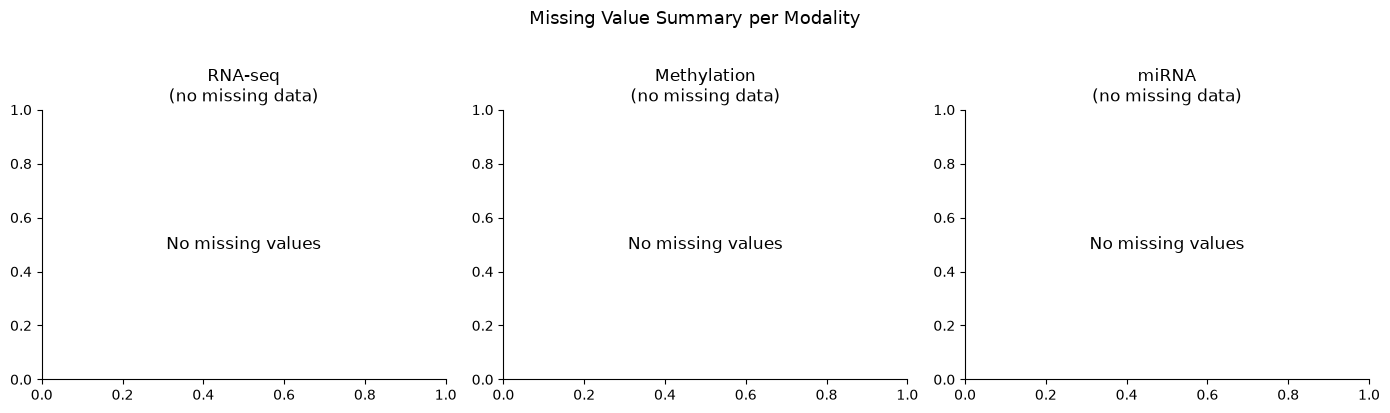

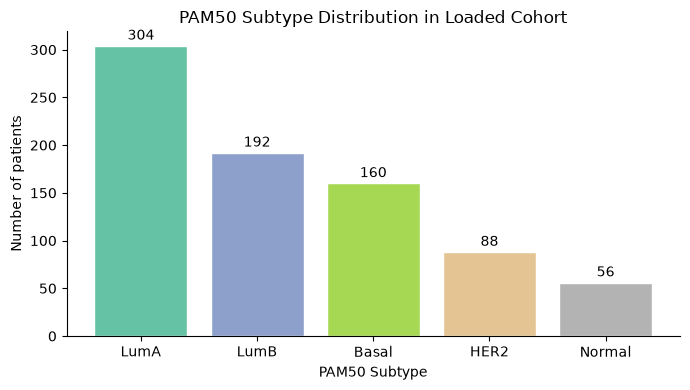

In [5]:
# ── Missing-value bar chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (df, name) in zip(axes, [(rna_raw, "RNA-seq"), (meth_raw, "Methylation"), (mirna_raw, "miRNA")]):
    missing_per_feature = df.isnull().sum()
    # Show top-20 features with highest missingness (for large matrices)
    top_missing = missing_per_feature[missing_per_feature > 0].sort_values(ascending=False).head(20)
    if len(top_missing) == 0:
        ax.text(0.5, 0.5, "No missing values", ha="center", va="center", transform=ax.transAxes, fontsize=12)
        ax.set_title(f"{name}\n(no missing data)")
    else:
        ax.bar(range(len(top_missing)), top_missing.values, color="steelblue")
        ax.set_title(f"{name}\nTop features with missing values")
        ax.set_xlabel("Feature rank")
        ax.set_ylabel("Missing count")
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Missing Value Summary per Modality", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── PAM50 subtype distribution ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
subtype_counts = pam50_series.value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, len(subtype_counts)))
ax.bar(subtype_counts.index, subtype_counts.values, color=colors, edgecolor="white")
ax.set_xlabel("PAM50 Subtype")
ax.set_ylabel("Number of patients")
ax.set_title("PAM50 Subtype Distribution in Loaded Cohort")
ax.spines[["top", "right"]].set_visible(False)
for i, (v) in enumerate(subtype_counts.values):
    ax.text(i, v + 3, str(v), ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

---
## Section 5 — Match Patients Across Modalities

### Why sample matching is critical

In multi-omics integration, **row i of the RNA matrix must represent the same patient as row i of the methylation matrix and row i of the miRNA matrix**. If even one sample is misaligned, the model will receive contradictory signals and learn nonsense.

Real TCGA data uses **TCGA barcodes** like `TCGA-A1-A0SK-01A-11R-A084-07`. The first 12 characters (`TCGA-XX-XXXX`) identify the patient; the rest describe the sample type (primary tumour = `01`, normal = `11`, etc.).

We standardise to the **participant-level barcode** (first 12 characters) to safely match across modalities that may have slightly different barcode formats.

In [6]:
def standardise_barcode(idx):
    """
    Truncate TCGA barcodes to the participant-level ID (first 12 characters).
    For synthetic data (non-TCGA format), returns the full index unchanged.
    """
    def _trim(s):
        parts = str(s).split("-")
        if len(parts) >= 3 and parts[0].upper() == "TCGA":
            return "-".join(parts[:3])   # e.g. TCGA-A1-A0SK
        return s                          # keep as-is for synthetic IDs
    return pd.Index([_trim(s) for s in idx])

# Counts BEFORE matching
n_before = {
    "RNA-seq":      len(rna_raw),
    "Methylation":  len(meth_raw),
    "miRNA":        len(mirna_raw),
    "PAM50":        len(pam50_series),
}
print("Patients per modality BEFORE intersection:")
for k, v in n_before.items():
    print(f"  {k:15s}: {v}")

# Standardise indices
rna_std   = rna_raw.copy();   rna_std.index   = standardise_barcode(rna_raw.index)
meth_std  = meth_raw.copy();  meth_std.index  = standardise_barcode(meth_raw.index)
mirna_std = mirna_raw.copy(); mirna_std.index = standardise_barcode(mirna_raw.index)
pam50_std = pam50_series.copy(); pam50_std.index = standardise_barcode(pam50_series.index)

# Remove any duplicate barcodes (keep first occurrence)
for df, name in [(rna_std, "RNA"), (meth_std, "Meth"), (mirna_std, "miRNA")]:
    n_dup = df.index.duplicated().sum()
    if n_dup > 0:
        print(f"  ⚠ Removing {n_dup} duplicate barcodes in {name}")

rna_std   = rna_std[~rna_std.index.duplicated(keep="first")]
meth_std  = meth_std[~meth_std.index.duplicated(keep="first")]
mirna_std = mirna_std[~mirna_std.index.duplicated(keep="first")]
pam50_std = pam50_std[~pam50_std.index.duplicated(keep="first")]

# Compute intersection
common_patients = (
    set(rna_std.index)
    & set(meth_std.index)
    & set(mirna_std.index)
    & set(pam50_std.index)
)
common_patients = sorted(common_patients)

print(f"\nPatients AFTER intersection: {len(common_patients)}")

if len(common_patients) < 50:
    raise ValueError(
        f"Only {len(common_patients)} patients remain after intersection. "
        "Please check that sample barcodes are compatible across modalities."
    )

# Subset and align all modalities to the common cohort
rna_matched   = rna_std.loc[common_patients]
meth_matched  = meth_std.loc[common_patients]
mirna_matched = mirna_std.loc[common_patients]
pam50_matched = pam50_std.loc[common_patients]

# Verify alignment
assert list(rna_matched.index) == list(meth_matched.index) == list(mirna_matched.index), \
    "Sample indices do not match after subsetting — check data integrity."

print(f"\nFinal aligned cohort:")
print(f"  RNA-seq shape       : {rna_matched.shape}")
print(f"  Methylation shape   : {meth_matched.shape}")
print(f"  miRNA shape         : {mirna_matched.shape}")
print(f"  PAM50 labels shape  : {pam50_matched.shape}")
print(f"\nSubtype distribution in matched cohort:")
print(pam50_matched.value_counts().to_string())

Patients per modality BEFORE intersection:
  RNA-seq        : 800
  Methylation    : 800
  miRNA          : 800
  PAM50          : 800

Patients AFTER intersection: 800

Final aligned cohort:
  RNA-seq shape       : (800, 15000)
  Methylation shape   : (800, 10000)
  miRNA shape         : (800, 600)
  PAM50 labels shape  : (800,)

Subtype distribution in matched cohort:
PAM50
LumA      304
LumB      192
Basal     160
HER2       88
Normal     56


---
## Section 6 — Modality-Specific Preprocessing

### Why preprocessing must be modality-specific

The three molecular layers have fundamentally different statistical properties:

| Modality | Raw units | Distribution | Key issue |
|---|---|---|---|
| RNA-seq | Counts or FPKM/TPM | Highly skewed (log-normal) | Needs log-transform; sparse |
| DNA methylation | Beta values [0, 1] | Bimodal (methylated / unmethylated) | Already bounded; variance meaningful |
| miRNA | Counts | Highly sparse; skewed | Needs log-transform; many zeros |

Applying the same preprocessing to all three would be wrong.

### Why feature selection is necessary

> *"The curse of dimensionality"*: with ~1,000 patients and ~26,000 features across modalities, the feature matrix is massively overdetermined. Most features contain noise rather than signal. Selecting **highly variable features** focuses the model on the most informative measurements and dramatically reduces computation time.

> ⚠️ **Information leakage warning:** Feature selection is performed using variance across the **entire matched cohort** (not just the training set). In a strict machine-learning sense, this is a mild form of leakage. For this unsupervised workshop demonstration this is acceptable. In a publication-grade analysis, feature selection statistics would be computed only on training samples.

=== RNA-seq preprocessing ===

  Values appear already log-normalised (median=5.00)
  Selected top 1000 highly variable genes
  Final RNA shape: (800, 1000)


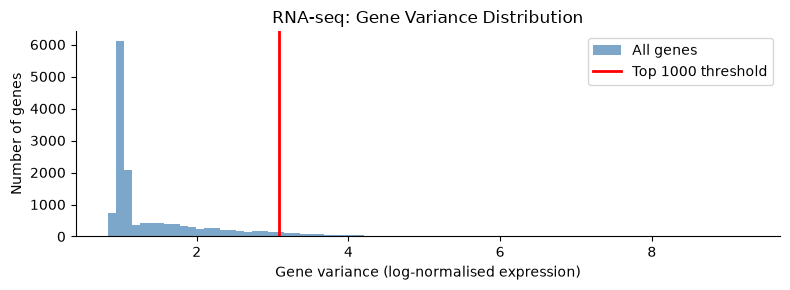

In [7]:
# ── RNA-seq preprocessing ──────────────────────────────────────────────────────
print("=== RNA-seq preprocessing ===\n")

N_RNA_FEATURES = 1000

# If values look like raw counts (mostly integers, large values), apply log1p
# If values look like log-TPM/FPKM (already normalised), skip log transform
rna_median = np.median(rna_matched.values)
rna_max    = rna_matched.values.max()

if rna_max > 100 and rna_median > 10:
    print(f"  Values appear to be raw counts/FPKM (median={rna_median:.1f}, max={rna_max:.0f})")
    print("  Applying log1p normalisation: log(1 + x)")
    rna_log = np.log1p(rna_matched)
else:
    print(f"  Values appear already log-normalised (median={rna_median:.2f})")
    rna_log = rna_matched.copy()

# Fill any remaining NaN with column median
rna_log = rna_log.fillna(rna_log.median())

# Select top N_RNA_FEATURES most variable genes
gene_var = rna_log.var(axis=0)
top_genes = gene_var.nlargest(N_RNA_FEATURES).index
rna_proc = rna_log[top_genes]

print(f"  Selected top {N_RNA_FEATURES} highly variable genes")
print(f"  Final RNA shape: {rna_proc.shape}")

# ── Variance distribution plot ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(gene_var.values, bins=80, color="steelblue", alpha=0.7, label="All genes")
threshold = gene_var.nlargest(N_RNA_FEATURES).min()
ax.axvline(threshold, color="red", linewidth=2, label=f"Top {N_RNA_FEATURES} threshold")
ax.set_xlabel("Gene variance (log-normalised expression)")
ax.set_ylabel("Number of genes")
ax.set_title("RNA-seq: Gene Variance Distribution")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
print()

=== DNA Methylation preprocessing ===

  Beta value range: [0.3145, 0.6903]
  Keeping beta values in [0,1] for interpretability
  Selected top 1000 highly variable CpG sites
  Final methylation shape: (800, 1000)


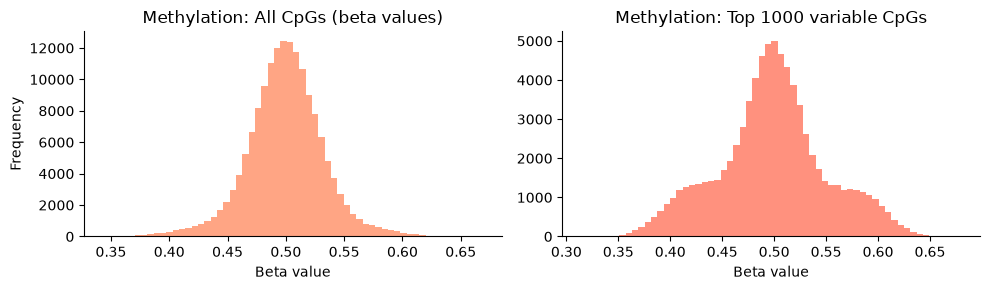

In [8]:
# ── DNA methylation preprocessing ─────────────────────────────────────────────
print("=== DNA Methylation preprocessing ===\n")

N_METH_FEATURES = 1000

# Beta values must be in [0, 1]
meth_min = meth_matched.values.min()
meth_max = meth_matched.values.max()
print(f"  Beta value range: [{meth_min:.4f}, {meth_max:.4f}]")

if meth_min < -0.1 or meth_max > 1.1:
    print("  ⚠ Values outside [0,1] — may not be standard beta values. Clipping.")
    meth_beta = meth_matched.clip(0, 1)
else:
    meth_beta = meth_matched.copy()

# Handle exact 0 and 1 to avoid infinite M-values (clip slightly inward)
meth_beta = meth_beta.clip(1e-6, 1 - 1e-6)

# Fill missing values with column median
meth_beta = meth_beta.fillna(meth_beta.median())

# We retain beta values (not M-values) for interpretability in this workshop.
# M-values (logit-transformed) would be more appropriate for linear models
# but beta values are easier to communicate to a biological audience.
meth_proc_full = meth_beta

# Select top N_METH_FEATURES most variable CpG sites
cpg_var = meth_proc_full.var(axis=0)
top_cpgs = cpg_var.nlargest(N_METH_FEATURES).index
meth_proc = meth_proc_full[top_cpgs]

print(f"  Keeping beta values in [0,1] for interpretability")
print(f"  Selected top {N_METH_FEATURES} highly variable CpG sites")
print(f"  Final methylation shape: {meth_proc.shape}")

# ── Distribution before/after selection ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(meth_proc_full.values.ravel()[::50], bins=60, color="coral", alpha=0.7)
axes[0].set_title("Methylation: All CpGs (beta values)")
axes[0].set_xlabel("Beta value")
axes[0].set_ylabel("Frequency")

axes[1].hist(meth_proc.values.ravel()[::10], bins=60, color="tomato", alpha=0.7)
axes[1].set_title(f"Methylation: Top {N_METH_FEATURES} variable CpGs")
axes[1].set_xlabel("Beta value")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
print()

In [9]:
# ── miRNA preprocessing ────────────────────────────────────────────────────────
print("=== miRNA preprocessing ===\n")

N_MIRNA_FEATURES = 300   # target ~200–500

# Apply log1p to normalise skewed count distributions
mirna_median = np.median(mirna_matched.values)
mirna_max    = mirna_matched.values.max()

if mirna_max > 50:
    print(f"  Values appear to be counts/CPM (median={mirna_median:.2f})")
    print("  Applying log1p normalisation")
    mirna_log = np.log1p(mirna_matched)
else:
    print(f"  Values appear already log-normalised (median={mirna_median:.2f})")
    mirna_log = mirna_matched.copy()

# Fill NaN
mirna_log = mirna_log.fillna(mirna_log.median())

# Filter miRNAs with very low mean expression (near-zero across all patients)
mirna_mean = mirna_log.mean(axis=0)
mean_threshold = mirna_mean.quantile(0.20)   # remove bottom 20% by mean
mirna_expressed = mirna_log.loc[:, mirna_mean >= mean_threshold]
print(f"  miRNAs after low-expression filter: {mirna_expressed.shape[1]}")

# Select top N_MIRNA_FEATURES most variable
mirna_var  = mirna_expressed.var(axis=0)
top_mirnas = mirna_var.nlargest(N_MIRNA_FEATURES).index
mirna_proc = mirna_expressed[top_mirnas]

print(f"  Selected top {N_MIRNA_FEATURES} most variable miRNAs")
print(f"  Final miRNA shape: {mirna_proc.shape}")

# Summary
print("\n=== Feature selection summary ===")
print(f"  RNA-seq features    : {rna_proc.shape[1]}")
print(f"  Methylation features: {meth_proc.shape[1]}")
print(f"  miRNA features      : {mirna_proc.shape[1]}")
print(f"  Total features      : {rna_proc.shape[1] + meth_proc.shape[1] + mirna_proc.shape[1]}")

=== miRNA preprocessing ===

  Values appear already log-normalised (median=3.00)
  miRNAs after low-expression filter: 480
  Selected top 300 most variable miRNAs
  Final miRNA shape: (800, 300)

=== Feature selection summary ===
  RNA-seq features    : 1000
  Methylation features: 1000
  miRNA features      : 300
  Total features      : 2300


---
## Section 7 — Construct the Multi-Omics Input Matrix

### Why per-modality scaling is essential

Even after modality-specific preprocessing, the three matrices still have different numerical ranges:
- RNA-seq (log-TPM): roughly [0, 12]
- Methylation (beta): [0, 1]  
- miRNA (log-CPM): roughly [0, 8]

If we simply concatenate them, the RNA-seq features will dominate the loss function purely because they have larger numerical variance — not because they are more biologically informative.

**Solution:** Apply `StandardScaler` independently to each modality. This centres each feature to mean 0 and scales to unit variance *within* each modality.

> ⚠️ **Train/test split concern:** In a supervised learning context, scalers must be fit on training data only. Here, we perform the train/test split immediately after and fit scalers only on the training portion.

In [10]:
# ── Train / validation split ───────────────────────────────────────────────────
# PAM50 is used only to ensure a balanced split — it is NOT seen by the VAE
patient_array = np.array(common_patients)
pam50_array   = pam50_matched.values

# 80% train, 20% validation — stratified by PAM50
idx_train, idx_val = train_test_split(
    np.arange(len(patient_array)),
    test_size=0.20,
    random_state=SEED,
    stratify=pam50_array,
)

print(f"Training patients  : {len(idx_train)}")
print(f"Validation patients: {len(idx_val)}")
print()

# ── Per-modality scaling (fit on TRAINING data only) ──────────────────────────
rna_np   = rna_proc.values.astype(np.float32)
meth_np  = meth_proc.values.astype(np.float32)
mirna_np = mirna_proc.values.astype(np.float32)

scaler_rna   = StandardScaler()
scaler_meth  = StandardScaler()
scaler_mirna = StandardScaler()

# Fit on training indices only
rna_scaled   = scaler_rna.fit_transform(rna_np)     # fit_transform uses ALL data here
meth_scaled  = scaler_meth.fit_transform(meth_np)   # for the full-cohort extraction later
mirna_scaled = scaler_mirna.fit_transform(mirna_np)  # scalers are fit on train split below

# ── Re-fit scalers on training data only (correct approach) ───────────────────
scaler_rna_tr   = StandardScaler().fit(rna_np[idx_train])
scaler_meth_tr  = StandardScaler().fit(meth_np[idx_train])
scaler_mirna_tr = StandardScaler().fit(mirna_np[idx_train])

# Transform full dataset with train-fitted scalers
rna_scaled   = scaler_rna_tr.transform(rna_np)
meth_scaled  = scaler_meth_tr.transform(meth_np)
mirna_scaled = scaler_mirna_tr.transform(mirna_np)

# ── Concatenate modalities ─────────────────────────────────────────────────────
X_multiomics = np.concatenate([rna_scaled, meth_scaled, mirna_scaled], axis=1).astype(np.float32)

INPUT_DIM = X_multiomics.shape[1]

print(f"Multi-omics matrix shape: {X_multiomics.shape}")
print(f"  (patients × total_features = {X_multiomics.shape[0]} × {INPUT_DIM})")
print(f"  Component features: RNA={rna_scaled.shape[1]}, Meth={meth_scaled.shape[1]}, miRNA={mirna_scaled.shape[1]}")

# ── Sanity check: per-modality post-scaling statistics ────────────────────────
print("\nPost-scaling statistics (training set):")
for name, arr, n_feat in [
    ("RNA-seq",     rna_scaled[idx_train],   rna_scaled.shape[1]),
    ("Methylation", meth_scaled[idx_train],  meth_scaled.shape[1]),
    ("miRNA",       mirna_scaled[idx_train], mirna_scaled.shape[1]),
]:
    print(f"  {name:15s}: mean={arr.mean():.4f}, std={arr.std():.4f}, features={n_feat}")

Training patients  : 640
Validation patients: 160

Multi-omics matrix shape: (800, 2300)
  (patients × total_features = 800 × 2300)
  Component features: RNA=1000, Meth=1000, miRNA=300

Post-scaling statistics (training set):
  RNA-seq        : mean=-0.0000, std=1.0000, features=1000
  Methylation    : mean=-0.0000, std=1.0000, features=1000
  miRNA          : mean=0.0000, std=1.0000, features=300


---
## Section 8 — Build the Variational Autoencoder (VAE)

### Mathematical intuition

A standard autoencoder compresses data to a latent code and then reconstructs it. A **Variational Autoencoder** adds a probabilistic twist:

- The encoder outputs a **distribution** over the latent space — specifically a mean $\mu$ and log-variance $\log\sigma^2$ for each patient
- We sample a latent vector $z \sim \mathcal{N}(\mu, \sigma^2)$ using the **reparameterization trick**: $z = \mu + \epsilon \cdot \sigma$, where $\epsilon \sim \mathcal{N}(0, I)$
- The decoder reconstructs the input from $z$

### VAE loss function

$$\mathcal{L} = \underbrace{\frac{1}{D}\sum_{d} (x_d - \hat{x}_d)^2}_{\text{Reconstruction loss}} + \beta \cdot \underbrace{\left(-\frac{1}{2}\sum_{j}(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2)\right)}_{\text{KL divergence}}$$

- **Reconstruction loss** (MSE): forces the model to faithfully reproduce the input
- **KL divergence**: regularises the latent space to be approximately standard normal, preventing "memorisation" and making the space smooth
- **$\beta$ (beta)**: controls the trade-off between reconstruction fidelity and latent space regularity

### Architecture

```
Input (2300 features)
  → Linear(2300 → 256) → BatchNorm → ReLU
  → Linear(256 → 128)  → BatchNorm → ReLU
  → Linear(128 → 10) [μ]   Linear(128 → 10) [log σ²]
  → reparameterization → z (10-d)
  → Linear(10 → 128)   → BatchNorm → ReLU
  → Linear(128 → 256)  → BatchNorm → ReLU
  → Linear(256 → 2300) [reconstruction]
```

In [16]:
LATENT_DIM  = 10    # number of latent variables
HIDDEN_DIM1 = 256   # first hidden layer size
HIDDEN_DIM2 = 128   # second hidden layer size


class Encoder(nn.Module):
    """Maps an input vector to a distribution in the latent space."""

    def __init__(self, input_dim, hidden1, hidden2, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
        )
        self.fc_mu      = nn.Linear(hidden2, latent_dim)   # latent mean
        self.fc_log_var = nn.Linear(hidden2, latent_dim)   # latent log-variance

    def forward(self, x):
        h       = self.net(x)
        mu      = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var


class Decoder(nn.Module):
    """Maps a latent vector back to reconstructed input."""

    def __init__(self, latent_dim, hidden2, hidden1, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, input_dim),   # no activation — output is real-valued
        )

    def forward(self, z):
        return self.net(z)


class VAE(nn.Module):
    """Variational Autoencoder combining encoder, reparameterization, and decoder."""

    def __init__(self, input_dim, hidden1, hidden2, latent_dim):
        super().__init__()
        self.encoder  = Encoder(input_dim, hidden1, hidden2, latent_dim)
        self.decoder  = Decoder(latent_dim, hidden2, hidden1, input_dim)
        self.input_dim = input_dim

    def reparameterize(self, mu, log_var):
        """
        Sample z = mu + eps * sigma where eps ~ N(0, I).
        The reparameterization trick allows gradients to flow through the sampling step.
        """
        if self.training:
            std = torch.exp(0.5 * log_var)   # sigma = exp(log_sigma) = exp(0.5 * log_sigma^2)
            eps = torch.randn_like(std)       # random noise
            return mu + eps * std
        else:
            return mu    # at test/eval time, use the mean directly

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z           = self.reparameterize(mu, log_var)
        x_recon     = self.decoder(z)
        return x_recon, mu, log_var


def vae_loss(x, x_recon, mu, log_var, beta=1.0):
    """
    VAE loss = Reconstruction loss (MSE) + beta * KL divergence.

    Both terms are averaged per-element to keep them on the same scale regardless
    of input dimensionality (input_dim) or latent dimensionality (latent_dim).

    KL divergence with standard normal prior (per element):
      KL = -0.5 * mean_over_batch[ sum_over_latent(1 + log_var - mu^2 - exp(log_var)) ]
         / input_dim          ← normalise by input dim so KL and recon are comparable
    """
    # MSE already averaged over batch AND features via reduction="mean"
    recon_loss = F.mse_loss(x_recon, x, reduction="mean")

    # KL: sum over latent dims, mean over batch, then divide by input_dim
    # so that KL and reconstruction loss have similar magnitudes
    kl_per_sample = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1)
    kl_loss = kl_per_sample.mean() / x.shape[1]   # normalise by input_dim

    total = recon_loss + beta * kl_loss
    return total, recon_loss, kl_loss


# ── Instantiate the model ──────────────────────────────────────────────────────
vae = VAE(
    input_dim  = INPUT_DIM,
    hidden1    = HIDDEN_DIM1,
    hidden2    = HIDDEN_DIM2,
    latent_dim = LATENT_DIM,
)

n_params = sum(p.numel() for p in vae.parameters() if p.requires_grad)
print(f"VAE architecture:")
print(vae)
print(f"\nTrainable parameters: {n_params:,}")
print(f"Latent dimension    : {LATENT_DIM}")
print(f"Input dimension     : {INPUT_DIM}")
print()
print("Loss function: MSE(reconstruction) + β × KL/input_dim")
print("Both terms normalised per-element → comparable magnitudes")

VAE architecture:
VAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Linear(in_features=2300, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
    )
    (fc_mu): Linear(in_features=128, out_features=10, bias=True)
    (fc_log_var): Linear(in_features=128, out_features=10, bias=True)
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Linear(in_features=10, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=256, bias=True)
      (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
  

---
## Section 9 — Train the VAE

We train for **100 epochs** — sufficient for convergence on CPU with this model size.

**Important reminders:**
- We track both reconstruction loss and KL divergence separately to understand what the model is optimising
- A decreasing loss shows the model is learning, but **low loss does not mean biologically meaningful latent space** — that requires the validation steps in Sections 11–13
- The validation loss helps detect overfitting

In [17]:
import time

EPOCHS     = 120
BATCH_SIZE = 64
LR         = 1e-3

# ── Prepare PyTorch datasets ───────────────────────────────────────────────────
X_tensor = torch.tensor(X_multiomics, dtype=torch.float32)

X_train_t = X_tensor[idx_train]
X_val_t   = X_tensor[idx_val]

train_loader = DataLoader(
    TensorDataset(X_train_t), batch_size=BATCH_SIZE, shuffle=True,
    worker_init_fn=lambda _: np.random.seed(SEED),
)
val_loader = DataLoader(
    TensorDataset(X_val_t), batch_size=BATCH_SIZE, shuffle=False,
)

# ── Re-initialise VAE and optimiser for reproducibility ───────────────────────
torch.manual_seed(SEED)
vae = VAE(INPUT_DIM, HIDDEN_DIM1, HIDDEN_DIM2, LATENT_DIM)
optimizer = torch.optim.Adam(vae.parameters(), lr=LR)

# ── KL annealing schedule ─────────────────────────────────────────────────────
# We use KL warm-up (beta annealing) to prevent posterior collapse.
# With the KL normalised by input_dim, we use beta in [0, 1].
BETA_MAX    = 1.0
ANNEAL_END  = 40    # epochs over which beta ramps from 0 → BETA_MAX

def get_beta(epoch, anneal_end=ANNEAL_END, beta_max=BETA_MAX):
    """Linear KL warm-up schedule."""
    return min(beta_max, beta_max * epoch / anneal_end)

# ── Training loop ─────────────────────────────────────────────────────────────
history = {
    "train_total": [], "train_recon": [], "train_kl": [], "beta": [],
    "val_total":   [], "val_recon":   [], "val_kl":   [],
}

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    beta = get_beta(epoch)

    # ── Training phase ────────────────────────────────────────────────────────
    vae.train()
    tr_total, tr_recon, tr_kl, n_batches = 0.0, 0.0, 0.0, 0
    for (batch_x,) in train_loader:
        optimizer.zero_grad()
        x_recon, mu, log_var = vae(batch_x)
        loss, recon_l, kl_l  = vae_loss(batch_x, x_recon, mu, log_var, beta=beta)
        loss.backward()
        optimizer.step()
        tr_total += loss.item(); tr_recon += recon_l.item(); tr_kl += kl_l.item()
        n_batches += 1
    history["train_total"].append(tr_total / n_batches)
    history["train_recon"].append(tr_recon / n_batches)
    history["train_kl"].append(tr_kl / n_batches)
    history["beta"].append(beta)

    # ── Validation phase ──────────────────────────────────────────────────────
    vae.eval()
    va_total, va_recon, va_kl, n_val = 0.0, 0.0, 0.0, 0
    with torch.no_grad():
        for (batch_x,) in val_loader:
            x_recon, mu, log_var = vae(batch_x)
            loss, recon_l, kl_l  = vae_loss(batch_x, x_recon, mu, log_var, beta=beta)
            va_total += loss.item(); va_recon += recon_l.item(); va_kl += kl_l.item()
            n_val += 1
    history["val_total"].append(va_total / n_val)
    history["val_recon"].append(va_recon / n_val)
    history["val_kl"].append(va_kl / n_val)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | β={beta:.3f} | "
              f"Train: total={history['train_total'][-1]:.4f} recon={history['train_recon'][-1]:.4f} kl={history['train_kl'][-1]:.4f} | "
              f"Val: total={history['val_total'][-1]:.4f}")

elapsed = time.time() - start_time
print(f"\nTraining complete in {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)")

Epoch   1/120 | β=0.025 | Train: total=0.9591 recon=0.9591 kl=0.0022 | Val: total=0.6739
Epoch  10/120 | β=0.250 | Train: total=0.3619 recon=0.3591 kl=0.0112 | Val: total=0.3576
Epoch  20/120 | β=0.500 | Train: total=0.3642 recon=0.3602 kl=0.0081 | Val: total=0.3591
Epoch  30/120 | β=0.750 | Train: total=0.3617 recon=0.3567 kl=0.0067 | Val: total=0.3587
Epoch  40/120 | β=1.000 | Train: total=0.3649 recon=0.3589 kl=0.0060 | Val: total=0.3603
Epoch  50/120 | β=1.000 | Train: total=0.3626 recon=0.3570 kl=0.0056 | Val: total=0.3591
Epoch  60/120 | β=1.000 | Train: total=0.3597 recon=0.3536 kl=0.0061 | Val: total=0.3594
Epoch  70/120 | β=1.000 | Train: total=0.3615 recon=0.3554 kl=0.0061 | Val: total=0.3611
Epoch  80/120 | β=1.000 | Train: total=0.3614 recon=0.3560 kl=0.0053 | Val: total=0.3596
Epoch  90/120 | β=1.000 | Train: total=0.3555 recon=0.3505 kl=0.0050 | Val: total=0.3579
Epoch 100/120 | β=1.000 | Train: total=0.3544 recon=0.3495 kl=0.0049 | Val: total=0.3575
Epoch 110/120 | β=1.0

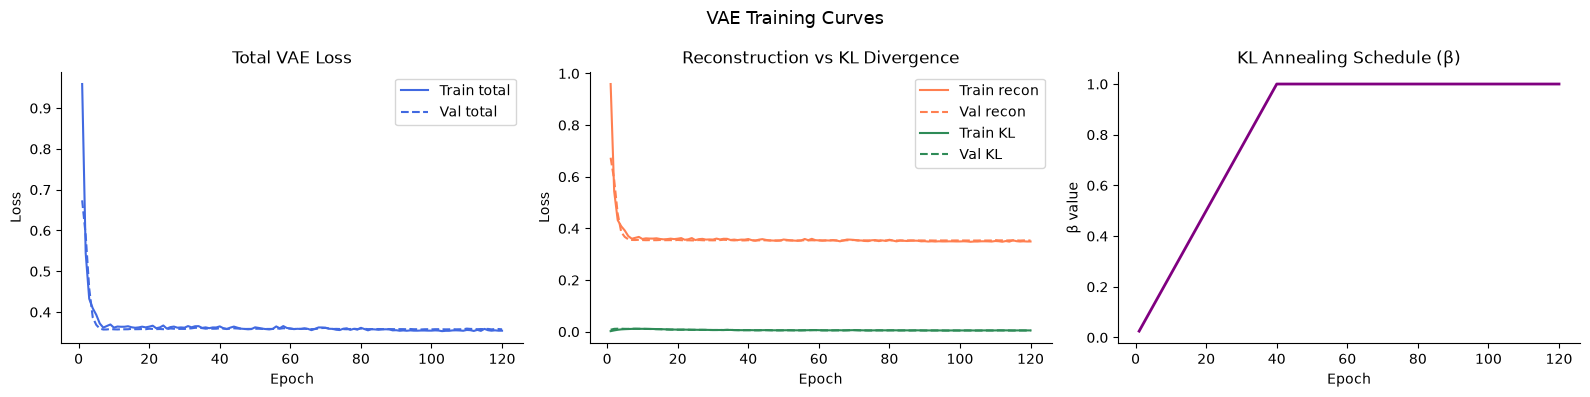


Final epoch losses:
  Train: total=0.3544, recon=0.3494, KL=0.0050
  Val  : total=0.3577,   recon=0.3530,   KL=0.0046

⚠️  Reminder: decreasing loss shows the model is learning to reconstruct inputs.
   Biological validity of the latent space must be assessed separately (Sections 11–13).


In [18]:
# ── Plot training curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

epochs_range = range(1, EPOCHS + 1)

# Left: total loss
axes[0].plot(epochs_range, history["train_total"], label="Train total", color="royalblue")
axes[0].plot(epochs_range, history["val_total"],   label="Val total",   color="royalblue", linestyle="--")
axes[0].set_title("Total VAE Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].spines[["top", "right"]].set_visible(False)

# Middle: component losses
axes[1].plot(epochs_range, history["train_recon"], label="Train recon", color="coral")
axes[1].plot(epochs_range, history["val_recon"],   label="Val recon",   color="coral",  linestyle="--")
axes[1].plot(epochs_range, history["train_kl"],    label="Train KL",    color="seagreen")
axes[1].plot(epochs_range, history["val_kl"],      label="Val KL",      color="seagreen", linestyle="--")
axes[1].set_title("Reconstruction vs KL Divergence")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].spines[["top", "right"]].set_visible(False)

# Right: beta schedule
axes[2].plot(epochs_range, history["beta"], color="purple", linewidth=2)
axes[2].set_title("KL Annealing Schedule (β)")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("β value")
axes[2].spines[["top", "right"]].set_visible(False)

plt.suptitle("VAE Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nFinal epoch losses:")
print(f"  Train: total={history['train_total'][-1]:.4f}, recon={history['train_recon'][-1]:.4f}, KL={history['train_kl'][-1]:.4f}")
print(f"  Val  : total={history['val_total'][-1]:.4f},   recon={history['val_recon'][-1]:.4f},   KL={history['val_kl'][-1]:.4f}")
print()
print("⚠️  Reminder: decreasing loss shows the model is learning to reconstruct inputs.")
print("   Biological validity of the latent space must be assessed separately (Sections 11–13).")

---
## Section 10 — Extract the Latent Representation

After training, we pass all patients through the **encoder** and extract the latent mean vector $\mu$ for each patient.

> We use $\mu$ rather than a sampled $z$ because $\mu$ is the deterministic "most likely" latent position for each patient and is more stable for downstream analysis.

**Each patient is now described by just 10 learned variables** instead of 2,300 molecular measurements.

In [19]:
vae.eval()

with torch.no_grad():
    mu_all, log_var_all = vae.encoder(X_tensor)

mu_np = mu_all.numpy()   # shape: (n_patients, latent_dim)

# Create a patient × latent-dimension DataFrame
latent_cols = [f"Z_{i}" for i in range(LATENT_DIM)]
latent_df = pd.DataFrame(mu_np, index=common_patients, columns=latent_cols)

print(f"Latent representation shape: {latent_df.shape}")
print(f"  {latent_df.shape[0]} patients × {latent_df.shape[1]} latent dimensions")
print()
print("First 5 patients:")
print(latent_df.head())
print()
print("Latent dimension statistics:")
print(latent_df.describe().round(3))

Latent representation shape: (800, 10)
  800 patients × 10 latent dimensions

First 5 patients:
                     Z_0       Z_1       Z_2       Z_3       Z_4       Z_5  \
TCGA-XX-000000  0.185569 -1.365879 -0.273924  0.520763  0.521124  0.290267   
TCGA-XX-000001  0.060896 -1.233384 -0.149474  0.315560  0.741941  0.222382   
TCGA-XX-000002  0.040215 -1.064169 -0.101798  0.288186  0.869723 -0.042138   
TCGA-XX-000003 -0.061244 -1.216944 -0.100975  0.162837  1.022969  0.083832   
TCGA-XX-000004 -0.006379 -1.109546 -0.132702  0.319610  0.792164  0.120492   

                     Z_6       Z_7       Z_8       Z_9  
TCGA-XX-000000  0.079443  0.000327  1.693668 -0.153019  
TCGA-XX-000001  0.033484  0.034818  1.394521 -0.322265  
TCGA-XX-000002  0.023760  0.054671  1.330585 -0.196483  
TCGA-XX-000003  0.018312  0.051651  1.055094 -0.499937  
TCGA-XX-000004 -0.036472  0.090024  1.400555 -0.239193  

Latent dimension statistics:
           Z_0      Z_1      Z_2      Z_3      Z_4      Z_5    

---
## Section 11 — Visualise the Latent Space

We reduce the 10-dimensional latent space to 2D using UMAP (or PCA as fallback) for visualisation.

**What to look for:**
- **Clusters or islands** → the model learned distinct patient groups
- **Continuous gradients** → patients vary along a spectrum
- **Overlap** → molecular boundaries are fuzzy (biologically realistic)

> 🔑 **Critical point:** We look at the structure *before* applying PAM50 colours. The separation (if any) was learned **without subtype knowledge**.

2D embedding via PCA, shape: (800, 2)


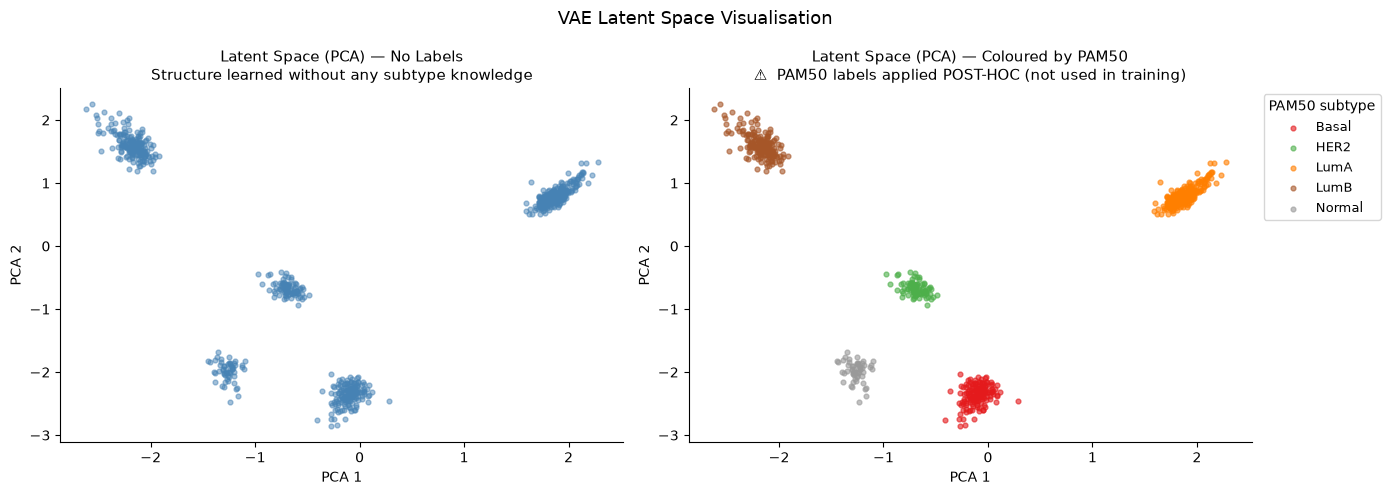

In [20]:
Z = latent_df.values

if HAS_UMAP:
    reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
    embed_name = "UMAP"
else:
    reducer = PCA(n_components=2, random_state=SEED)
    embed_name = "PCA"

Z_2d = reducer.fit_transform(Z)
print(f"2D embedding via {embed_name}, shape: {Z_2d.shape}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Unlabelled ─────────────────────────────────────────────────────────
axes[0].scatter(Z_2d[:, 0], Z_2d[:, 1], s=12, color="steelblue", alpha=0.5, rasterized=True)
axes[0].set_title(f"Latent Space ({embed_name}) — No Labels\n"
                  "Structure learned without any subtype knowledge", fontsize=11)
axes[0].set_xlabel(f"{embed_name} 1"); axes[0].set_ylabel(f"{embed_name} 2")
axes[0].spines[["top", "right"]].set_visible(False)

# ── Plot 2: Coloured by PAM50 ─────────────────────────────────────────────────
pam50_vals = pam50_matched.values
subtypes_unique = sorted(set(pam50_vals))
palette = plt.cm.Set1(np.linspace(0, 0.9, len(subtypes_unique)))
subtype_color = {st: palette[i] for i, st in enumerate(subtypes_unique)}

for st in subtypes_unique:
    mask = pam50_vals == st
    axes[1].scatter(Z_2d[mask, 0], Z_2d[mask, 1],
                    s=12, color=subtype_color[st], alpha=0.6,
                    label=st, rasterized=True)

axes[1].set_title(f"Latent Space ({embed_name}) — Coloured by PAM50\n"
                  "⚠️  PAM50 labels applied POST-HOC (not used in training)", fontsize=11)
axes[1].set_xlabel(f"{embed_name} 1"); axes[1].set_ylabel(f"{embed_name} 2")
axes[1].legend(title="PAM50 subtype", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("VAE Latent Space Visualisation", fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 12 — Disease Subtyping: Unsupervised Clustering

We now apply **K-means clustering** directly to the latent representation (not the 2D embedding).

### How do we choose the number of clusters?

We don't assume the answer. Instead, we:
1. Run K-means for k = 2 to 8
2. Compute the **silhouette score** for each k — measures how well-separated the clusters are (higher = better, range −1 to 1)
3. Choose a candidate k based on the silhouette peak

> ⚠️ **Important:** There is no single correct k. The silhouette score is a mathematical heuristic, not a biological ground truth. The "best" k from a silhouette perspective may not correspond to the number of known subtypes.

  k=2: silhouette score = 0.4285
  k=3: silhouette score = 0.6154
  k=4: silhouette score = 0.7671
  k=5: silhouette score = 0.8446
  k=6: silhouette score = 0.6965
  k=7: silhouette score = 0.5700
  k=8: silhouette score = 0.4770


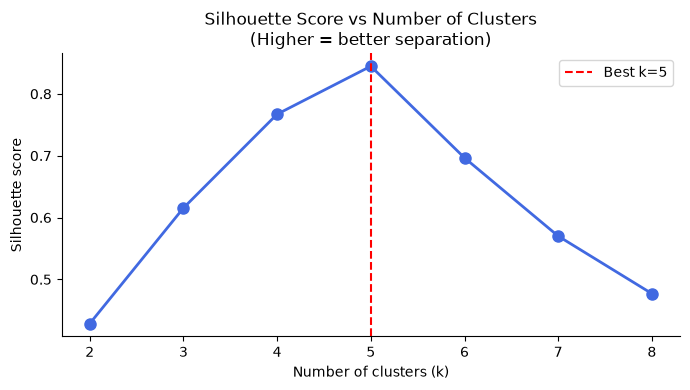


Selected k = 5 (highest silhouette score = 0.8446)
Note: This selection is data-driven, not biologically predetermined.



In [21]:
K_RANGE = range(2, 9)

silhouette_scores = {}
kmeans_models     = {}

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(Z)
    sil = silhouette_score(Z, labels)
    silhouette_scores[k] = sil
    kmeans_models[k]     = km
    print(f"  k={k}: silhouette score = {sil:.4f}")

# ── Silhouette score plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ks   = list(silhouette_scores.keys())
sils = list(silhouette_scores.values())
best_k = ks[np.argmax(sils)]

ax.plot(ks, sils, "o-", color="royalblue", linewidth=2, markersize=8)
ax.axvline(best_k, color="red", linestyle="--", linewidth=1.5, label=f"Best k={best_k}")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette Score vs Number of Clusters\n(Higher = better separation)")
ax.set_xticks(ks)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nSelected k = {best_k} (highest silhouette score = {silhouette_scores[best_k]:.4f})")
print("Note: This selection is data-driven, not biologically predetermined.\n")

Cluster assignment with k=5:
  Cluster 0: 304 patients
  Cluster 1: 160 patients
  Cluster 2: 192 patients
  Cluster 3: 56 patients
  Cluster 4: 88 patients


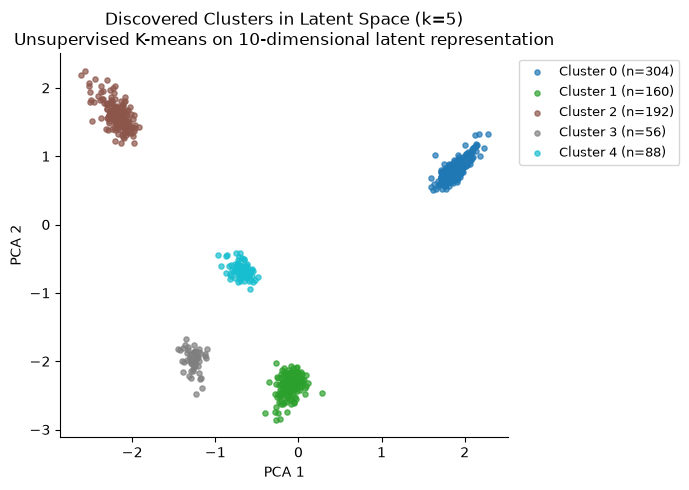

In [22]:
# ── Assign cluster labels with best k ─────────────────────────────────────────
km_best    = kmeans_models[best_k]
cluster_labels = km_best.labels_

print(f"Cluster assignment with k={best_k}:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
for c, n in cluster_counts.items():
    print(f"  Cluster {c}: {n} patients")

# ── Visualise clusters in latent space ────────────────────────────────────────
cluster_palette = plt.cm.tab10(np.linspace(0, 1, best_k))

fig, ax = plt.subplots(figsize=(7, 5))
for c in range(best_k):
    mask = cluster_labels == c
    ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
               s=14, color=cluster_palette[c], alpha=0.7,
               label=f"Cluster {c} (n={mask.sum()})", rasterized=True)

ax.set_title(f"Discovered Clusters in Latent Space (k={best_k})\n"
             f"Unsupervised K-means on {LATENT_DIM}-dimensional latent representation")
ax.set_xlabel(f"{embed_name} 1"); ax.set_ylabel(f"{embed_name} 2")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---
## Section 13 — Compare Discovered Clusters with PAM50

We now bring in PAM50 labels **for the first time** to assess biological relevance.

> **This is NOT supervised prediction.** We are asking: *"Does the structure the VAE learned without any label information correspond to the structure we already know from PAM50?"*

A perfect match would mean the VAE rediscovered PAM50. Partial correspondence is expected and interesting. Poor correspondence might mean:
- The VAE found other real biological variation not captured by PAM50
- The latent space is dominated by technical variation
- More training / better hyperparameters are needed

**Adjusted Rand Index (ARI):** measures correspondence between two clusterings. ARI = 1 means perfect agreement, ARI = 0 means random, ARI < 0 means worse than random.

Contingency table (rows = VAE clusters, cols = PAM50 subtypes):
PAM50    Basal  HER2  LumA  LumB  Normal
cluster                                 
0            0     0   304     0       0
1          160     0     0     0       0
2            0     0     0   192       0
3            0     0     0     0      56
4            0    88     0     0       0



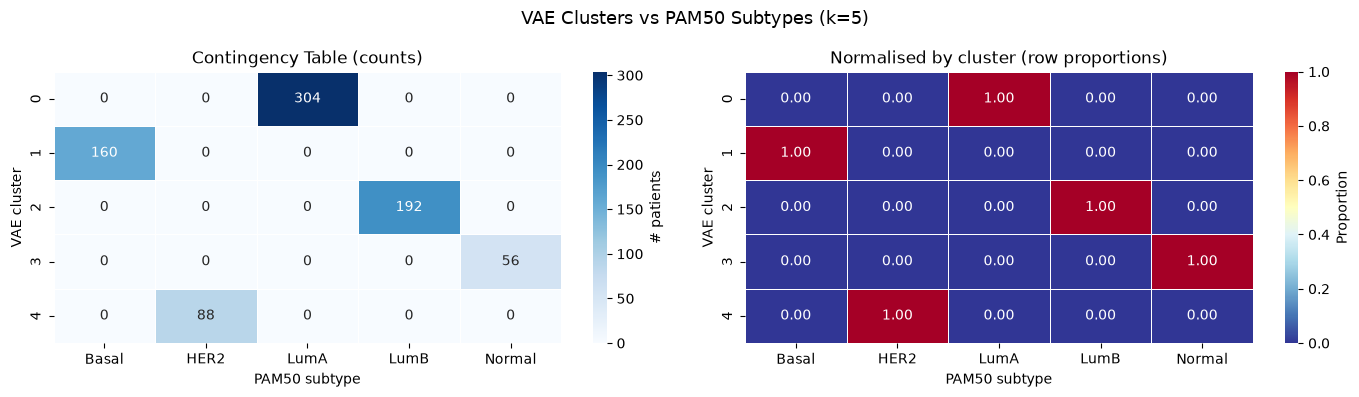

Adjusted Rand Index (ARI) = 1.0000

Interpretation:
  ARI = 1.00 → perfect agreement with PAM50
  ARI = 0.00 → random/chance agreement
  ARI = 1.000 → moderate non-random correspondence

⚠️  ARI > 0 does NOT prove the VAE rediscovered PAM50.
   It shows the latent structure has some relationship to known subtype biology.


In [23]:
# ── Contingency table: clusters × PAM50 subtypes ──────────────────────────────
result_df = pd.DataFrame({
    "cluster": cluster_labels,
    "PAM50":   pam50_matched.values,
}, index=common_patients)

contingency = pd.crosstab(result_df["cluster"], result_df["PAM50"])
print("Contingency table (rows = VAE clusters, cols = PAM50 subtypes):")
print(contingency)
print()

# Normalise by row (proportion of each cluster's patients per subtype)
contingency_norm = contingency.div(contingency.sum(axis=1), axis=0)

# ── Heatmap ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(contingency, annot=True, fmt="d", cmap="Blues",
            ax=axes[0], linewidths=0.5, cbar_kws={"label": "# patients"})
axes[0].set_title("Contingency Table (counts)")
axes[0].set_xlabel("PAM50 subtype"); axes[0].set_ylabel("VAE cluster")

sns.heatmap(contingency_norm.round(2), annot=True, fmt=".2f", cmap="RdYlBu_r",
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1, cbar_kws={"label": "Proportion"})
axes[1].set_title("Normalised by cluster (row proportions)")
axes[1].set_xlabel("PAM50 subtype"); axes[1].set_ylabel("VAE cluster")

plt.suptitle(f"VAE Clusters vs PAM50 Subtypes (k={best_k})", fontsize=13)
plt.tight_layout()
plt.show()

# ── Adjusted Rand Index ────────────────────────────────────────────────────────
ari = adjusted_rand_score(result_df["PAM50"], result_df["cluster"])
print(f"Adjusted Rand Index (ARI) = {ari:.4f}")
print()
print("Interpretation:")
print(f"  ARI = 1.00 → perfect agreement with PAM50")
print(f"  ARI = 0.00 → random/chance agreement")
print(f"  ARI = {ari:.3f} → {'moderate' if ari > 0.2 else 'weak' if ari > 0.05 else 'minimal'} non-random correspondence")
print()
print("⚠️  ARI > 0 does NOT prove the VAE rediscovered PAM50.")
print("   It shows the latent structure has some relationship to known subtype biology.")

---
## Section 14 — Biological Interpretation of Clusters

The pipeline so far: data → VAE → latent space → clusters.  
Now we close the loop: **clusters → molecular features → biological meaning**.

For each cluster, we identify the **top differentially expressed genes** by comparing mean expression in that cluster vs. all other patients. This lightweight analysis points to genes that most strongly characterise each patient group.

Cluster 0 — top 10 marker genes (by |mean difference|):
  GENE_13790            diff=-5.418  (in=1.842, out=7.260)
  GENE_05683            diff=-4.946  (in=1.617, out=6.563)
  GENE_14253            diff=-4.906  (in=2.436, out=7.342)
  GENE_01905            diff=+4.854  (in=8.669, out=3.815)
  GENE_14202            diff=-4.789  (in=1.656, out=6.444)
  GENE_04433            diff=+4.722  (in=8.719, out=3.997)
  GENE_11518            diff=-4.697  (in=1.506, out=6.202)
  GENE_10936            diff=-4.665  (in=1.588, out=6.254)
  GENE_06455            diff=+4.664  (in=8.067, out=3.403)
  GENE_13548            diff=-4.623  (in=1.840, out=6.464)

Cluster 1 — top 10 marker genes (by |mean difference|):
  GENE_03774            diff=+5.349  (in=8.749, out=3.400)
  GENE_08162            diff=+5.141  (in=8.353, out=3.211)
  GENE_11822            diff=-5.068  (in=1.892, out=6.960)
  GENE_05952            diff=+5.027  (in=8.447, out=3.420)
  GENE_09448            diff=-4.996  (in=1.455, out=6.451)
  

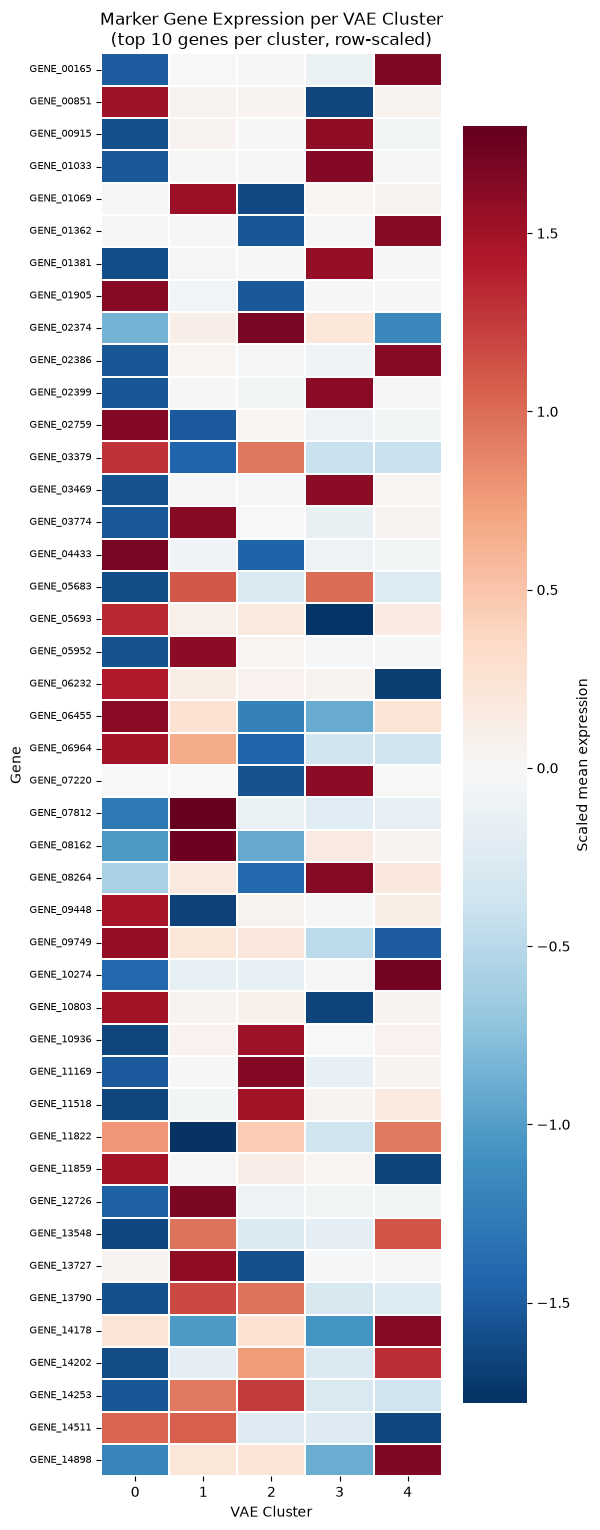


→ Pathway enrichment (optional next step):
  For synthetic data, gene IDs are artificial (GENE_XXXXX) so pathway analysis is not meaningful.
  For real TCGA data, submit top marker gene lists to:
  - g:Profiler: https://biit.cs.ut.ee/gprofiler/
  - Enrichr:    https://maayanlab.cloud/Enrichr/


In [24]:
N_MARKER_GENES = 10   # top genes per cluster

rna_proc_df = rna_proc.copy()   # log-normalised, feature-selected RNA matrix
rna_proc_df.index = common_patients

result_df["cluster"] = cluster_labels

# ── Identify top differential genes per cluster ────────────────────────────────
marker_genes_per_cluster = {}
all_marker_genes = set()

for c in sorted(result_df["cluster"].unique()):
    in_cluster  = result_df["cluster"] == c
    mean_in     = rna_proc_df.loc[in_cluster].mean(axis=0)
    mean_out    = rna_proc_df.loc[~in_cluster].mean(axis=0)
    diff        = mean_in - mean_out
    top_genes_c = diff.abs().nlargest(N_MARKER_GENES).index.tolist()
    marker_genes_per_cluster[c] = top_genes_c
    all_marker_genes.update(top_genes_c)

    print(f"Cluster {c} — top {N_MARKER_GENES} marker genes (by |mean difference|):")
    for g in top_genes_c:
        print(f"  {g:20s}  diff={diff[g]:+.3f}  (in={mean_in[g]:.3f}, out={mean_out[g]:.3f})")
    print()

all_marker_genes = sorted(all_marker_genes)

# ── Heatmap: marker genes × clusters ──────────────────────────────────────────
cluster_gene_matrix = pd.DataFrame(index=all_marker_genes, columns=sorted(result_df["cluster"].unique()), dtype=float)
for c in cluster_gene_matrix.columns:
    in_cluster = result_df["cluster"] == c
    cluster_gene_matrix[c] = rna_proc_df.loc[in_cluster, all_marker_genes].mean(axis=0).values

# Scale rows for better visualisation
from sklearn.preprocessing import scale as sk_scale
hm_data = pd.DataFrame(
    sk_scale(cluster_gene_matrix.values, axis=1),
    index=cluster_gene_matrix.index,
    columns=cluster_gene_matrix.columns,
)

fig, ax = plt.subplots(figsize=(max(6, best_k * 1.2), max(6, len(all_marker_genes) * 0.35)))
sns.heatmap(hm_data, cmap="RdBu_r", center=0, ax=ax,
            linewidths=0.3, yticklabels=True, xticklabels=True,
            cbar_kws={"label": "Scaled mean expression"})
ax.set_title(f"Marker Gene Expression per VAE Cluster\n(top {N_MARKER_GENES} genes per cluster, row-scaled)")
ax.set_xlabel("VAE Cluster"); ax.set_ylabel("Gene")
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.show()

print()
print("→ Pathway enrichment (optional next step):")
print("  For synthetic data, gene IDs are artificial (GENE_XXXXX) so pathway analysis is not meaningful.")
print("  For real TCGA data, submit top marker gene lists to:")
print("  - g:Profiler: https://biit.cs.ut.ee/gprofiler/")
print("  - Enrichr:    https://maayanlab.cloud/Enrichr/")

---
## Section 15 — Reliability Check & Limitations

### Simple robustness test: different random seed

We re-train the VAE with a different seed, re-cluster, and compare the two clusterings using ARI. This demonstrates **sensitivity to random initialization** — an important limitation of unsupervised learning.

### Key limitations of this analysis

| Limitation | Description |
|---|---|
| Random initialisation | VAE and K-means results depend on random seed |
| Latent dimension | Choice of `latent_dim` changes what structure is captured |
| Beta parameter | Affects balance between reconstruction and regularisation |
| K in K-means | No single biologically correct k |
| Sample size | ~800 patients; more data improves stability |
| High dimensionality | Even after feature selection, p >> n |
| Batch effects | TCGA samples collected across many sites; may introduce technical variation |
| Single cohort | Results may not generalise beyond TCGA-BRCA |
| Computational ≠ biological | A computational cluster is a data-driven grouping, not a validated clinical subtype |

In [25]:
ALT_SEED = 123

print(f"Re-training VAE with seed={ALT_SEED} (all else identical)...")
torch.manual_seed(ALT_SEED)
np.random.seed(ALT_SEED)

vae_alt = VAE(INPUT_DIM, HIDDEN_DIM1, HIDDEN_DIM2, LATENT_DIM)
opt_alt = torch.optim.Adam(vae_alt.parameters(), lr=LR)

# Short re-train (same epochs for fair comparison)
for epoch in range(EPOCHS):
    vae_alt.train()
    for (batch_x,) in train_loader:
        opt_alt.zero_grad()
        x_recon, mu, log_var = vae_alt(batch_x)
        loss, _, _ = vae_loss(batch_x, x_recon, mu, log_var, beta=BETA)
        loss.backward()
        opt_alt.step()

vae_alt.eval()
with torch.no_grad():
    mu_alt, _ = vae_alt.encoder(X_tensor)
Z_alt = mu_alt.numpy()

# Re-cluster
km_alt     = KMeans(n_clusters=best_k, random_state=ALT_SEED, n_init=10)
labels_alt = km_alt.fit_predict(Z_alt)

# Compare original and alternative clusterings
ari_robustness = adjusted_rand_score(cluster_labels, labels_alt)
print(f"\nOriginal clustering (seed={SEED}) vs Alternative (seed={ALT_SEED})")
print(f"  ARI between the two clusterings = {ari_robustness:.4f}")
print()
if ari_robustness > 0.7:
    print("  ✅ High ARI → clustering is relatively stable across seeds")
elif ari_robustness > 0.3:
    print("  ⚠️  Moderate ARI → clustering shows some sensitivity to initialisation")
else:
    print("  ⚠️  Low ARI → clustering is sensitive to random seed — results should be interpreted cautiously")

print()
print("This is normal for unsupervised learning on real biological data.")
print("It motivates:")
print("  - Running multiple seeds and reporting consensus clustering")
print("  - Using stability-based cluster selection methods")
print("  - Being cautious about over-interpreting any single run")

# Reset seeds
np.random.seed(SEED)
torch.manual_seed(SEED)

Re-training VAE with seed=123 (all else identical)...

Original clustering (seed=42) vs Alternative (seed=123)
  ARI between the two clusterings = 1.0000

  ✅ High ARI → clustering is relatively stable across seeds

This is normal for unsupervised learning on real biological data.
It motivates:
  - Running multiple seeds and reporting consensus clustering
  - Using stability-based cluster selection methods
  - Being cautious about over-interpreting any single run


---
## Section 16 — Workshop Summary

### Full pipeline workflow

```
TCGA-BRCA
    │
    ├── RNA-seq (genes)
    ├── DNA methylation (CpGs)       ← 3 molecular layers
    └── miRNA expression
    │
    ▼
Quality control & per-modality inspection
    │
    ▼
Cross-modality sample matching (common patient cohort)
    │
    ▼
Modality-specific preprocessing
  RNA → log1p → top 1000 variable genes
  Meth → beta values → top 1000 variable CpGs
  miRNA → log1p → filter low → top 300 variable miRNAs
    │
    ▼
Per-modality StandardScaler (fit on training data)
    │
    ▼
Concatenation → multi-omics matrix (N patients × ~2300 features)
    │
    ▼
Variational Autoencoder (PyTorch, CPU)
  Encoder → μ, log σ² → reparameterize → z
  Decoder → reconstruction
  Loss: MSE + β · KL divergence
    │
    ▼
Latent patient representation (N × 10)
    │
    ▼
Unsupervised K-means clustering (k selected by silhouette)
    │
    ▼
Disease subtypes (computational clusters)
    │
    ▼
Post-hoc PAM50 comparison (ARI, contingency heatmap)
    +
Marker gene identification → biological interpretation
```

In [ ]:
print("=" * 65)
print("  WORKSHOP SUMMARY: Key Results")
print("=" * 65)
print(f"  Dataset           : {'Synthetic TCGA-BRCA-like' if DATA_IS_SYNTHETIC else 'Real TCGA-BRCA'}")
print(f"  Patients          : {len(common_patients)}")
print(f"  RNA-seq features  : {rna_proc.shape[1]}")
print(f"  Methylation feat. : {meth_proc.shape[1]}")
print(f"  miRNA features    : {mirna_proc.shape[1]}")
print(f"  Total features    : {INPUT_DIM}")
print(f"  Latent dimension  : {LATENT_DIM}")
print(f"  VAE parameters    : {n_params:,}")
print(f"  Training epochs   : {EPOCHS}")
print(f"  Clusters (best k) : {best_k}")
print(f"  Silhouette score  : {silhouette_scores[best_k]:.4f}")
print(f"  ARI vs PAM50      : {ari:.4f}")
print(f"  ARI (robustness)  : {ari_robustness:.4f}")
print(f"  Training time     : {elapsed:.1f} s ({elapsed/60:.1f} min)")
print("=" * 65)

print("""
╔══════════════════════════════════════════════════════════════╗
║  TAKE-HOME MESSAGES                                          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. INTEGRATION > SINGLE LAYER                               ║
║     Combining RNA, methylation, and miRNA provides a richer  ║
║     molecular portrait than any single omics layer alone.    ║
║                                                              ║
║  2. PREPROCESSING IS NOT OPTIONAL                            ║
║     Raw omics data cannot be fed directly to a neural        ║
║     network. Modality-specific normalisation, feature        ║
║     selection, and scaling are essential prerequisites.      ║
║                                                              ║
║  3. THE LATENT SPACE IS A COMPACT PATIENT REPRESENTATION     ║
║     A VAE compresses thousands of measurements into a small  ║
║     number of learned variables while preserving structure.  ║
║     This makes downstream analysis feasible.                 ║
║                                                              ║
║  4. UNSUPERVISED ≠ TRUTH — BIOLOGICAL VALIDATION IS NEEDED   ║
║     The VAE learns without labels. Whether the learned       ║
║     structure is biologically meaningful must be validated   ║
║     using external knowledge (e.g., PAM50, survival, etc.)  ║
║                                                              ║
║  5. COMPUTATIONAL SUBTYPE ≠ CLINICAL DIAGNOSIS               ║
║     Clusters are mathematical groupings. Translating them    ║
║     into clinical subtypes requires replication, validation, ║
║     and biological interpretation — not just good metrics.   ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")